# Seed-Guided RFdiffusion Binder Design — Figure Generation

Figures comparing seed-guided RFdiffusion designs (*SwanSeeds*) against the non-seed control (*RFD*), with BindCraft included as an external benchmark for secondary-structure composition.

All  filters are applied jointly: **`pae_interaction < 10`** AND **`total_contacts_4A ≥ 26`**.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Patch
from matplotlib.ticker import FuncFormatter

## Helper functions

Shared utilities for secondary-structure normalization, ternary-coordinate conversion, and percentage-axis formatting.

In [2]:
def find_col(df, pattern):
    """Find first column matching `pattern`, excluding `_stride` variants."""
    matches = [c for c in df.columns if pattern in c and '_stride' not in c]
    return matches[0] if matches else None


def calc_structure_ss(df):
    """Compute normalized helix / β-sheet / coil percentages from STRIDE columns."""
    helix_col    = find_col(df, 'Alpha_Helix_Percent')
    strand_col   = find_col(df, 'Beta_Strand_Percent')
    bridge_col   = find_col(df, 'Beta_Bridge_Percent')
    coil_col     = find_col(df, 'Coil_Percent')
    turn_col     = find_col(df, 'Turn_Percent')
    helix310_col = find_col(df, '3-10_Helix_Percent')
    df = df.copy()
    df['Helix']      = df[helix_col].fillna(0)
    df['Beta_Sheet'] = df[strand_col].fillna(0) + df[bridge_col].fillna(0)
    df['Coil']       = df[coil_col].fillna(0) + df[turn_col].fillna(0) + df[helix310_col].fillna(0)
    total = (df['Helix'] + df['Beta_Sheet'] + df['Coil']).replace(0, 1)
    df['Helix_Norm']      = df['Helix']      / total * 100
    df['Beta_Sheet_Norm'] = df['Beta_Sheet'] / total * 100
    df['Coil_Norm']       = df['Coil']       / total * 100
    return df


def ternary_to_cartesian(helix, beta_sheet, coil):
    """Convert (helix, β-sheet, coil) percentages to ternary Cartesian coordinates."""
    total = helix + beta_sheet + coil
    h = helix / total
    b = beta_sheet / total
    x = b + 0.5 * h
    y = (np.sqrt(3) / 2) * h
    return x, y


def add_ternary_grid_and_labels(ax):
    """Draw 20% gridlines, vertex labels, and tick labels on a ternary triangle."""
    for i in range(0, 101, 20):
        x1, y1 = ternary_to_cartesian(i, 100 - i, 0)
        x2, y2 = ternary_to_cartesian(i, 0, 100 - i)
        ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=0.5)
        x1, y1 = ternary_to_cartesian(0, i, 100 - i)
        x2, y2 = ternary_to_cartesian(100 - i, i, 0)
        ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=0.5)
        x1, y1 = ternary_to_cartesian(100 - i, 0, i)
        x2, y2 = ternary_to_cartesian(0, 100 - i, i)
        ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=0.5)

    ax.text(0.25 - 0.12, np.sqrt(3) / 4 + 0.06, 'α-Helix', ha='center', va='center',
            fontsize=20, fontweight='bold', rotation=60)
    ax.text(0.5, -0.10, 'Coil', ha='center', va='top', fontsize=20, fontweight='bold')
    ax.text(0.75 + 0.12, np.sqrt(3) / 4 + 0.06, 'β-Sheet', ha='center', va='center',
            fontsize=20, fontweight='bold', rotation=-60)

    for i in range(0, 101, 20):
        x_left = (i / 100) * 0.5
        y_left = (i / 100) * (np.sqrt(3) / 2)
        ax.text(x_left - np.sqrt(3) / 2 * 0.05, y_left + 0.5 * 0.05, f'{i}%',
                ha='center', va='center', fontsize=16, fontweight='bold', rotation=60)
        x_right = (1 - i / 100) * 0.5 + (i / 100) * 1
        y_right = (1 - i / 100) * (np.sqrt(3) / 2)
        ax.text(x_right + np.sqrt(3) / 2 * 0.05, y_right + 0.5 * 0.05, f'{i}%',
                ha='center', va='center', fontsize=16, fontweight='bold', rotation=-60)
        x_bottom = i / 100
        ax.text(x_bottom, -0.04, f'{100 - i}%', ha='center', va='top',
                fontsize=16, fontweight='bold')
    ax.text(0, -0.04, '100%', ha='center', va='top', fontsize=16, fontweight='bold')


def pct_fmt(x, _):
    """Tick formatter for percentage axes."""
    if x >= 1:   return f'{x:.0f}%'
    if x >= 0.1: return f'{x:.1f}%'
    if x == 0:   return '0%'
    return f'{x:.2f}%'


def styled_ternary_axes(figsize=(10, 10)):
    """Create a standard ternary-plot axis with the unit triangle drawn in."""
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    triangle = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2]])
    ax.add_patch(Polygon(triangle, closed=True, fill=False, edgecolor='black', linewidth=2))
    return fig, ax


def finalize_ternary(ax):
    """Apply consistent axis limits and remove spines for ternary plots."""
    add_ternary_grid_and_labels(ax)
    ax.set_xlim(-0.25, 1.25)
    ax.set_ylim(-0.25, np.sqrt(3) / 2 + 0.15)
    ax.set_aspect('equal')
    ax.axis('off')


## 1. Load data

All raw inputs are read here once. Downstream cells reuse these dataframes.

In [4]:
# Per-design merged metric tables
seed_merged    = pd.read_csv('seed_guided_merged.csv')
nonseed_merged = pd.read_csv('nonseed_control_merged.csv')
bindcraft_df   = pd.read_csv('merged_analysis_bindcraft_3.csv')

# Foldseek/TM-align cluster assignments (TM-score 0.5, contacts ≥ 26 cutoff)
seed_clust    = pd.read_csv('cluster_analysis_ss_tm05_c26.csv')
nonseed_clust = pd.read_csv('cluster_analysis_rfdc_tm05_c26.csv')

# Pairwise TM-score matrices (full, unfiltered)
K_seed_df    = pd.read_csv('tmscore_matrix_ss.csv',   index_col=0)
K_nonseed_df = pd.read_csv('tmscore_matrix_rfdc.csv', index_col=0)
seed_ids,    K_seed    = list(K_seed_df.index),    K_seed_df.values
nonseed_ids, K_nonseed = list(K_nonseed_df.index), K_nonseed_df.values

print(f"Seed merged:    {len(seed_merged):>5} designs")
print(f"Nonseed merged: {len(nonseed_merged):>5} designs")
print(f"BindCraft:      {len(bindcraft_df):>5} designs")
print(f"Seed TM matrix:    {K_seed.shape}")
print(f"Nonseed TM matrix: {K_nonseed.shape}")


Seed merged:    12000 designs
Nonseed merged: 12000 designs
BindCraft:        502 designs
Seed TM matrix:    (12000, 12000)
Nonseed TM matrix: (12000, 12000)


## 2. Quality filtering and derived quantities

Apply the joint quality cutoffs (`pae_interaction < 10` AND `total_contacts_4A ≥ 26`), then precompute per-figure inputs:

- **`*_filt`** — merged tables restricted to passing designs
- **`*_sizes`** / **`*_total`** — cluster size distributions
- **`K_sf` / `K_nf`** — TM-score submatrices restricted to passing designs
- **`*_scatter`** — subsets used for the ipAE-vs-contacts scatter (all designs, NaN dropped)

In [6]:
# 2a. Quality filters on per-design tables -----------------------------------
PAE_CUTOFF, CONTACTS_CUTOFF = 10, 26

def apply_quality_filter(df, contacts_col):
    return df[(df['pae_interaction'] < PAE_CUTOFF) &
              (df[contacts_col]      >= CONTACTS_CUTOFF)].copy()

seed_filt      = apply_quality_filter(seed_merged,    'total_contacts_4A')
nonseed_filt   = apply_quality_filter(nonseed_merged, 'total_contacts_4A')
bindcraft_filt = apply_quality_filter(bindcraft_df,   'contacts')  # different column name

print(f"Filtered structures — Seed: {len(seed_filt)}, "
      f"Nonseed: {len(nonseed_filt)}, BindCraft: {len(bindcraft_filt)}")

# 2b. Cluster size distributions ---------------------------------------------
seed_sizes    = seed_clust.groupby('cluster_representative').size().sort_values(ascending=False)
nonseed_sizes = nonseed_clust.groupby('cluster_representative').size().sort_values(ascending=False)
seed_total, nonseed_total = seed_sizes.sum(), nonseed_sizes.sum()

print(f"Clusters — Seed: {len(seed_sizes)} ({seed_total} structures), "
      f"Nonseed: {len(nonseed_sizes)} ({nonseed_total} structures)")

# 2c. TM-matrix subset to passing designs ------------------------------------
seed_pass    = set(seed_filt['structure_id'].dropna().values)
nonseed_pass = set(nonseed_filt['structure_id'].dropna().values)

seed_filt_idx    = np.array([i for i, sid in enumerate(seed_ids)    if sid in seed_pass])
nonseed_filt_idx = np.array([i for i, sid in enumerate(nonseed_ids) if sid in nonseed_pass])

K_sf = K_seed[np.ix_(seed_filt_idx,    seed_filt_idx)]
K_nf = K_nonseed[np.ix_(nonseed_filt_idx, nonseed_filt_idx)]
print(f"Filtered TM matrices — Seed: {K_sf.shape}, Nonseed: {K_nf.shape}")

# 2d. Scatter-plot subsets (no quality filter — used to *display* the cutoffs) -
scatter_cols = ['pae_interaction', 'total_contacts_4A', 'plddt_binder']
swan_scatter = seed_merged[scatter_cols].dropna()
rele_scatter = nonseed_merged[scatter_cols].dropna()
print(f"Scatter — Seed: {len(swan_scatter)} points, Nonseed: {len(rele_scatter)} points")


Filtered structures — Seed: 493, Nonseed: 146, BindCraft: 29
Clusters — Seed: 188 (493 structures), Nonseed: 54 (146 structures)
Filtered TM matrices — Seed: (493, 493), Nonseed: (146, 146)
Scatter — Seed: 12000 points, Nonseed: 12000 points


## 3. ipAE vs total contacts (colored by binder pLDDT)

Three panels: with seeds, without seeds, and the two overlaid. Marginal histograms share axes; the colorbar range is shared across the per-condition panels. Dashed red lines mark the quality cutoffs used downstream.

In [7]:
# Shared limits for axes/colorbar across the per-condition panels
pae_counts_swan,      _ = np.histogram(swan_scatter['pae_interaction'],   bins=30)
pae_counts_rele,      _ = np.histogram(rele_scatter['pae_interaction'],   bins=30)
contacts_counts_swan, _ = np.histogram(swan_scatter['total_contacts_4A'], bins=30)
contacts_counts_rele, _ = np.histogram(rele_scatter['total_contacts_4A'], bins=30)

histx_max = max(pae_counts_swan.max(),      pae_counts_rele.max())      * 1.1
histy_max = max(contacts_counts_swan.max(), contacts_counts_rele.max()) * 1.1

combined_plddt = pd.concat([swan_scatter['plddt_binder'], rele_scatter['plddt_binder']])
vmin_rounded = int(combined_plddt.min() // 10) * 10
vmax_rounded = int(combined_plddt.max() // 10 + 1) * 10
cbar_ticks   = np.arange(vmin_rounded, vmax_rounded + 1, 10)
y_min, y_max = 0, 50


### 3a. With seeds

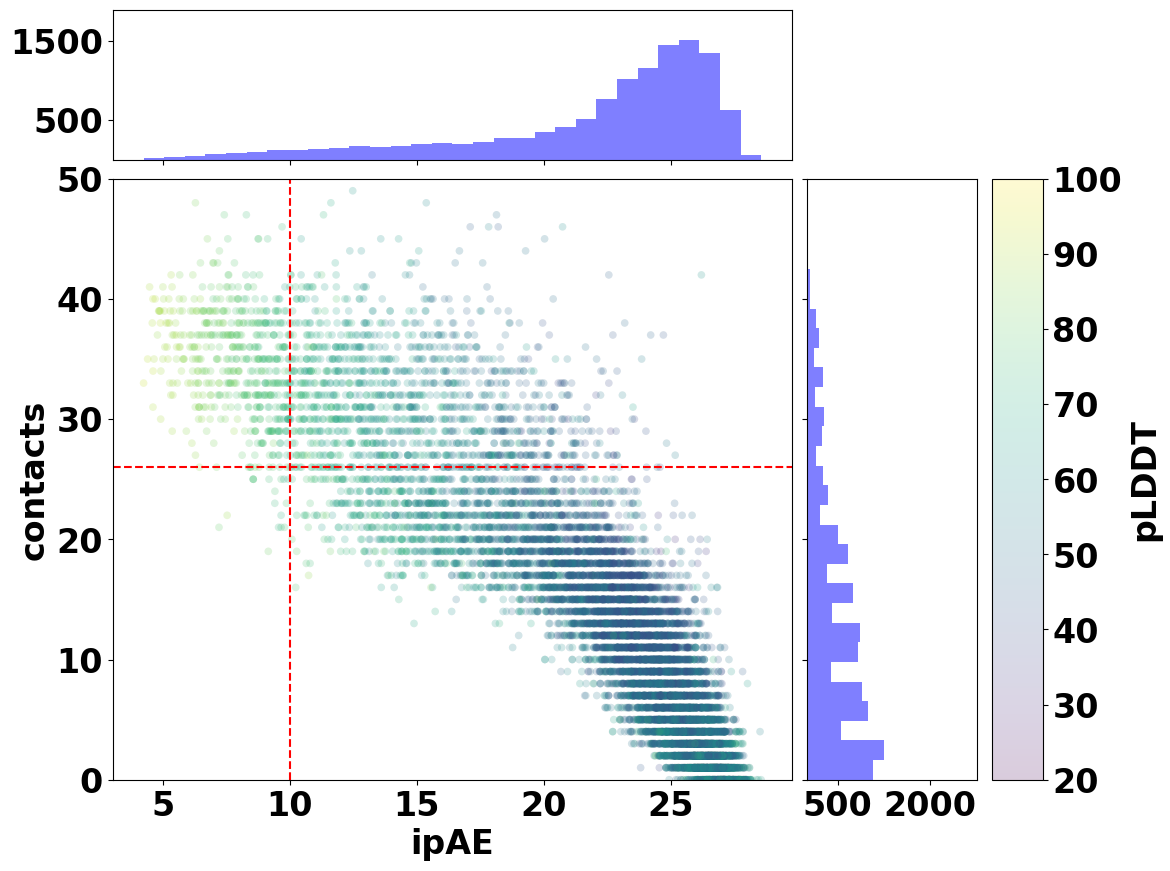

✓ pae_vs_contacts_withseeds.png


In [8]:
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 4], width_ratios=[4, 1, 0.3],
                      hspace=0.05, wspace=0.05)

ax1       = fig.add_subplot(gs[1, 0])
ax1_histx = fig.add_subplot(gs[0, 0], sharex=ax1)
ax1_histy = fig.add_subplot(gs[1, 1], sharey=ax1)
ax1_cbar  = fig.add_subplot(gs[1, 2])

ax1_histx.tick_params(axis='x', labelbottom=False)
ax1_histy.tick_params(axis='y', labelleft=False)
ax1_histx.set_ylim(0, histx_max)
ax1_histy.set_xlim(0, histy_max)

scatter1 = ax1.scatter(swan_scatter['pae_interaction'], swan_scatter['total_contacts_4A'],
                       c=swan_scatter['plddt_binder'], cmap='viridis',
                       alpha=0.2, s=30, linewidth=0.01,
                       vmin=vmin_rounded, vmax=vmax_rounded)

ax1.axvline(10, color='red', linestyle='--', linewidth=1.5)
ax1.axhline(26, color='red', linestyle='--', linewidth=1.5)

ax1.set_xlabel('ipAE',     fontsize=24, fontweight='bold')
ax1.set_ylabel('contacts', fontsize=24, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=24)
ax1.set_xticks(np.arange(0, 31, 5))
ax1.set_ylim(y_min, y_max)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight('bold')

ax1_histx.hist(swan_scatter['pae_interaction'],   bins=30, color='blue', alpha=0.5, edgecolor='none')
ax1_histy.hist(swan_scatter['total_contacts_4A'], bins=30, orientation='horizontal',
               color='blue', alpha=0.5, edgecolor='none')
ax1_histx.tick_params(axis='y', labelsize=24); ax1_histx.set_yticks([500, 1500])
ax1_histy.tick_params(axis='x', labelsize=24); ax1_histy.set_xticks([500, 2000])
for label in ax1_histx.get_yticklabels() + ax1_histy.get_xticklabels():
    label.set_fontweight('bold')

cbar1 = plt.colorbar(scatter1, cax=ax1_cbar)
cbar1.set_label('pLDDT', fontsize=24, fontweight='bold')
cbar1.set_ticks(cbar_ticks)
cbar1.ax.tick_params(labelsize=24)
for label in cbar1.ax.get_yticklabels():
    label.set_fontweight('bold')

plt.savefig('pae_vs_contacts_withseeds.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ pae_vs_contacts_withseeds.png")


### 3b. Without seeds

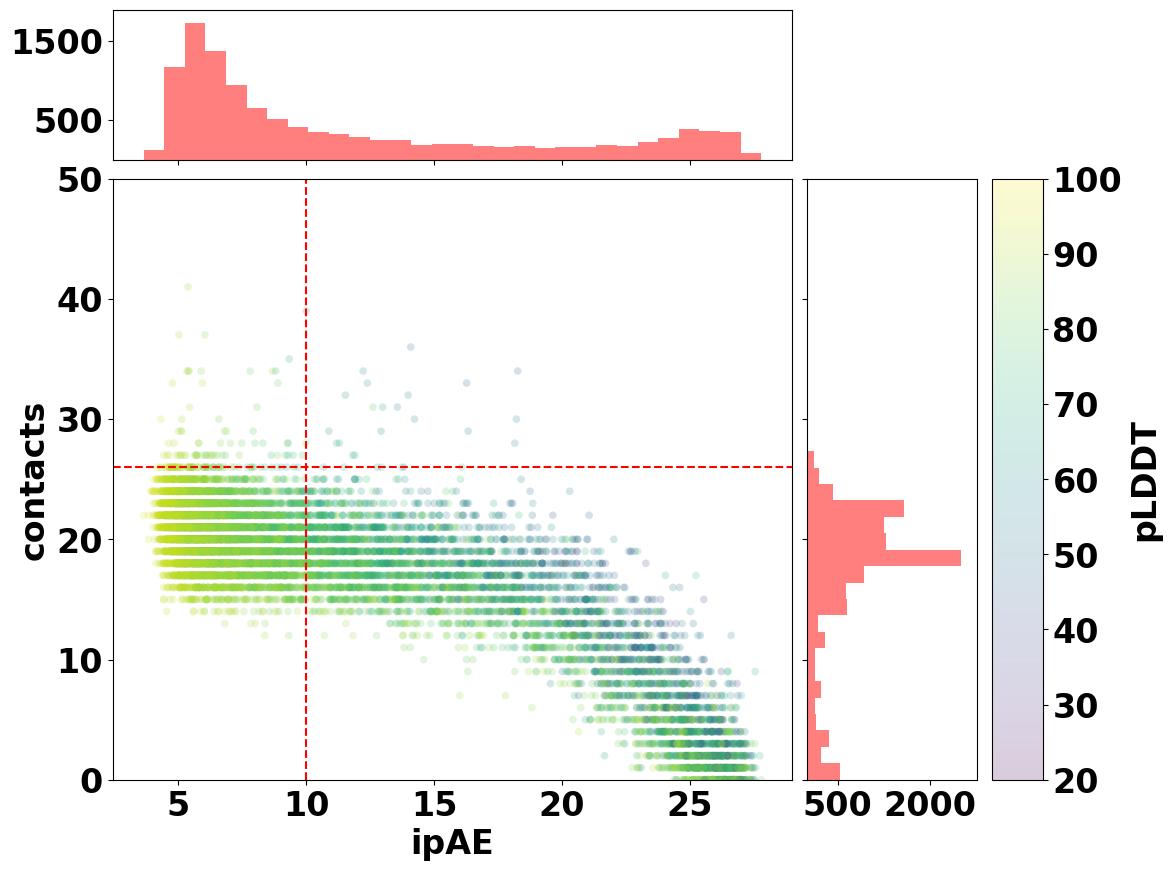

✓ pae_vs_contacts_withoutseeds.png


In [9]:
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 4], width_ratios=[4, 1, 0.3],
                      hspace=0.05, wspace=0.05)

ax2       = fig.add_subplot(gs[1, 0])
ax2_histx = fig.add_subplot(gs[0, 0], sharex=ax2)
ax2_histy = fig.add_subplot(gs[1, 1], sharey=ax2)
ax2_cbar  = fig.add_subplot(gs[1, 2])

ax2_histx.tick_params(axis='x', labelbottom=False)
ax2_histy.tick_params(axis='y', labelleft=False)
ax2_histx.set_ylim(0, histx_max)
ax2_histy.set_xlim(0, histy_max)

scatter2 = ax2.scatter(rele_scatter['pae_interaction'], rele_scatter['total_contacts_4A'],
                       c=rele_scatter['plddt_binder'], cmap='viridis',
                       alpha=0.2, s=30, linewidth=0.01,
                       vmin=vmin_rounded, vmax=vmax_rounded)

ax2.axvline(10, color='red', linestyle='--', linewidth=1.5)
ax2.axhline(26, color='red', linestyle='--', linewidth=1.5)

ax2.set_xlabel('ipAE',     fontsize=24, fontweight='bold')
ax2.set_ylabel('contacts', fontsize=24, fontweight='bold')
ax2.tick_params(axis='both', which='major', labelsize=24)
ax2.set_xticks(np.arange(0, 31, 5))
ax2.set_ylim(y_min, y_max)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_fontweight('bold')

ax2_histx.hist(rele_scatter['pae_interaction'],   bins=30, color='red', alpha=0.5, edgecolor='none')
ax2_histy.hist(rele_scatter['total_contacts_4A'], bins=30, orientation='horizontal',
               color='red', alpha=0.5, edgecolor='none')
ax2_histx.tick_params(axis='y', labelsize=24); ax2_histx.set_yticks([500, 1500])
ax2_histy.tick_params(axis='x', labelsize=24); ax2_histy.set_xticks([500, 2000])
for label in ax2_histx.get_yticklabels() + ax2_histy.get_xticklabels():
    label.set_fontweight('bold')

cbar2 = plt.colorbar(scatter2, cax=ax2_cbar)
cbar2.set_label('pLDDT', fontsize=24, fontweight='bold')
cbar2.set_ticks(cbar_ticks)
cbar2.ax.tick_params(labelsize=24)
for label in cbar2.ax.get_yticklabels():
    label.set_fontweight('bold')

plt.savefig('pae_vs_contacts_withoutseeds.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ pae_vs_contacts_withoutseeds.png")


### 3c. Overlay

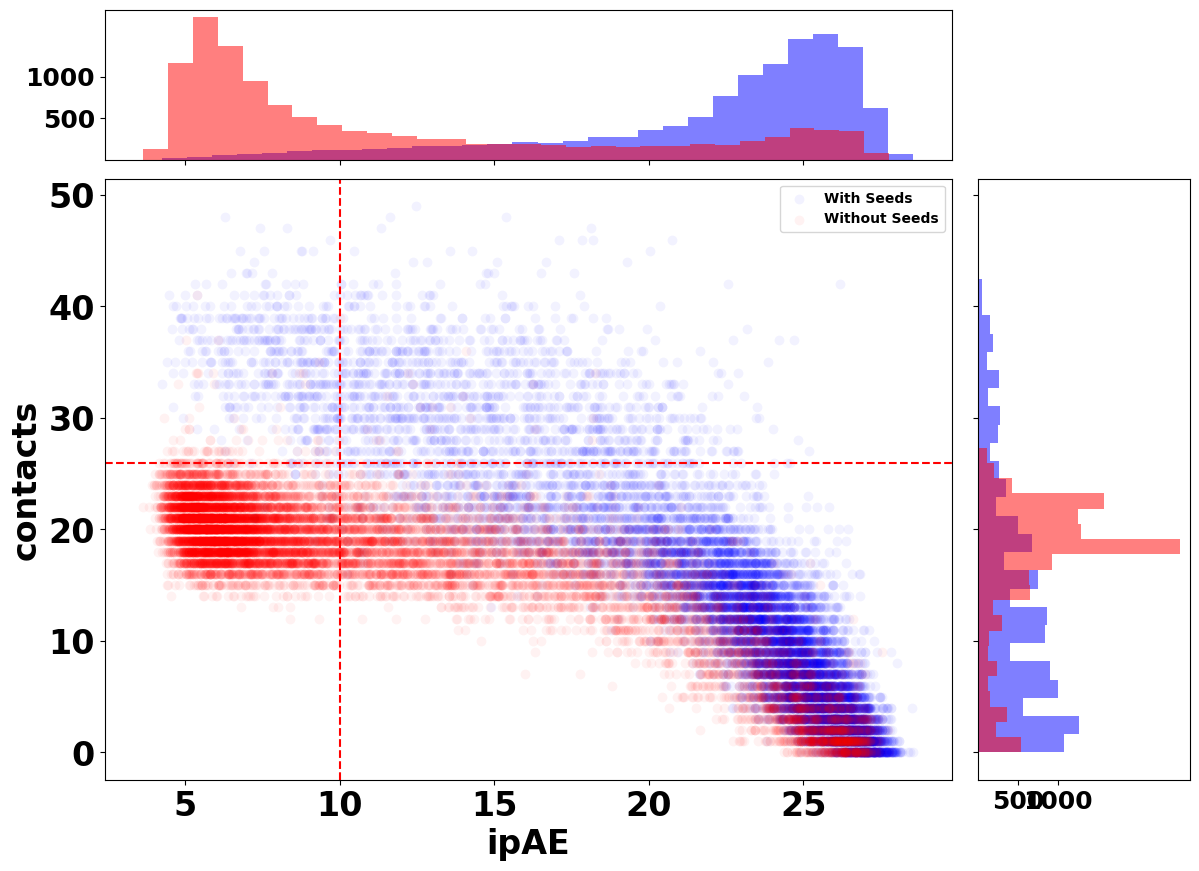

✓ pae_vs_contacts_combined.png


In [10]:
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 4], width_ratios=[4, 1],
                      hspace=0.05, wspace=0.05)

ax_main  = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_histx.tick_params(axis='x', labelbottom=False)
ax_histy.tick_params(axis='y', labelleft=False)

ax_main.scatter(swan_scatter['pae_interaction'], swan_scatter['total_contacts_4A'],
                c='blue', alpha=0.05, s=50, marker='o', label='With Seeds',
                edgecolors='black', linewidth=0.01)
ax_main.scatter(rele_scatter['pae_interaction'], rele_scatter['total_contacts_4A'],
                c='red',  alpha=0.05, s=50, marker='o', label='Without Seeds',
                edgecolors='black', linewidth=0.01)

ax_main.axvline(10, color='red', linestyle='--', linewidth=1.5)
ax_main.axhline(26, color='red', linestyle='--', linewidth=1.5)

ax_main.set_xlabel('ipAE',     fontsize=24, fontweight='bold')
ax_main.set_ylabel('contacts', fontsize=24, fontweight='bold')
ax_main.tick_params(axis='both', which='major', labelsize=24)
ax_main.set_xticks(np.arange(0, 31, 5))
for label in ax_main.get_xticklabels() + ax_main.get_yticklabels():
    label.set_fontweight('bold')

ax_histx.hist(swan_scatter['pae_interaction'], bins=30, color='blue', alpha=0.5, edgecolor='none', label='With Seeds')
ax_histx.hist(rele_scatter['pae_interaction'], bins=30, color='red',  alpha=0.5, edgecolor='none', label='Without Seeds')
ax_histy.hist(swan_scatter['total_contacts_4A'], bins=30, orientation='horizontal',
              color='blue', alpha=0.5, edgecolor='none')
ax_histy.hist(rele_scatter['total_contacts_4A'], bins=30, orientation='horizontal',
              color='red',  alpha=0.5, edgecolor='none')

ax_histx.tick_params(axis='y', labelsize=18); ax_histx.set_yticks([500, 1000])
ax_histy.tick_params(axis='x', labelsize=18); ax_histy.set_xticks([500, 1000])
for label in ax_histx.get_yticklabels() + ax_histy.get_xticklabels():
    label.set_fontweight('bold')

ax_main.legend(fontsize=24, prop={'weight': 'bold'})

plt.savefig('pae_vs_contacts_combined.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ pae_vs_contacts_combined.png")


## 4. Design filtering funnel

Stacked bars (log y-axis) showing the count of designs surviving each successive filter, side-by-side for the seeded and unseeded protocols.

With Seeds:    12000 → 1786 → 493 → 188
Without Seeds: 12000 → 173 → 146 → 54


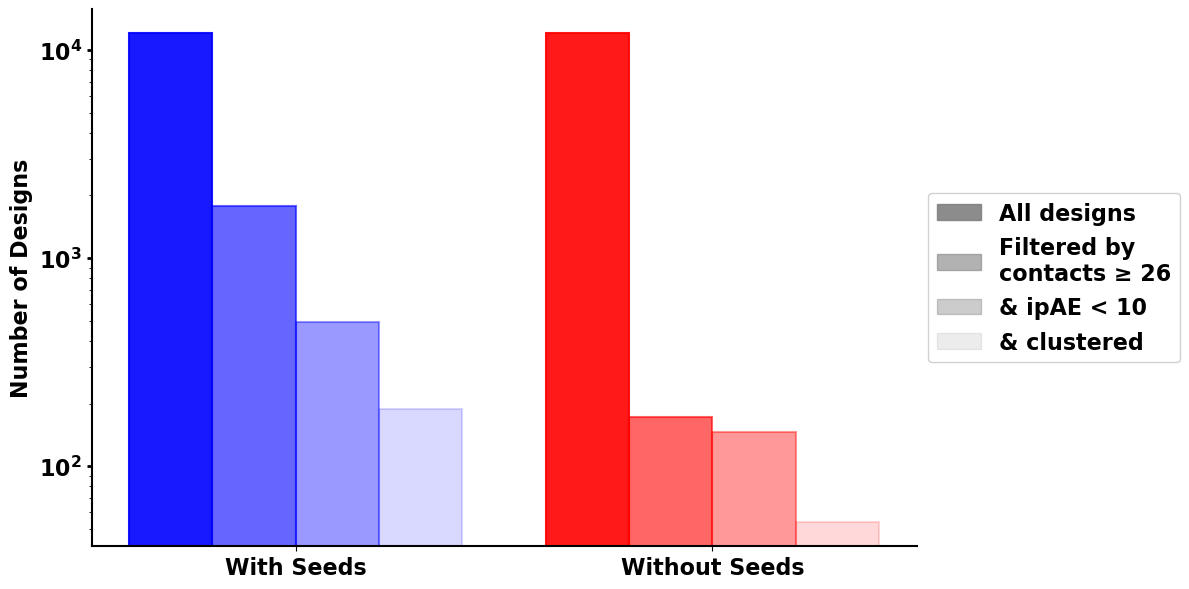

✓ designs_filter_bar_new.png


In [11]:
# Funnel counts at each filtering stage
swan_total    = len(seed_merged)
swan_contacts = (seed_merged['total_contacts_4A'] >= 26).sum()
swan_ipae     = len(seed_filt)
swan_clusters = seed_clust['cluster_representative'].nunique()

rele_total    = len(nonseed_merged)
rele_contacts = (nonseed_merged['total_contacts_4A'] >= 26).sum()
rele_ipae     = len(nonseed_filt)
rele_clusters = nonseed_clust['cluster_representative'].nunique()

print(f"With Seeds:    {swan_total} → {swan_contacts} → {swan_ipae} → {swan_clusters}")
print(f"Without Seeds: {rele_total} → {rele_contacts} → {rele_ipae} → {rele_clusters}")

swan_counts = [swan_total, swan_contacts, swan_ipae, swan_clusters]
rele_counts = [rele_total, rele_contacts, rele_ipae, rele_clusters]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.array([0, 1.5])
width = 0.3
alphas  = [0.9, 0.6, 0.4, 0.15]
offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width]

for j, (alpha, offset) in enumerate(zip(alphas, offsets)):
    ax.bar(x[0] + offset, swan_counts[j], width=width, color='blue', alpha=alpha,
           edgecolor='blue', linewidth=1.5)
    ax.bar(x[1] + offset, rele_counts[j], width=width, color='red',  alpha=alpha,
           edgecolor='red',  linewidth=1.5)

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(['With Seeds', 'Without Seeds'], fontsize=16, fontweight='bold')
ax.set_ylabel('Number of Designs', fontsize=16, fontweight='bold')
ax.tick_params(axis='y', labelsize=16, width=2)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

legend_elements = [
    Patch(facecolor='gray', alpha=0.9,  edgecolor='gray', label='All designs'),
    Patch(facecolor='gray', alpha=0.6,  edgecolor='gray', label='Filtered by\ncontacts ≥ 26'),
    Patch(facecolor='gray', alpha=0.4,  edgecolor='gray', label='& ipAE < 10'),
    Patch(facecolor='gray', alpha=0.15, edgecolor='gray', label='& clustered'),
]
legend = ax.legend(handles=legend_elements, fontsize=16, framealpha=0.9,
                   loc='center left', bbox_to_anchor=(1.0, 0.5))
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
plt.savefig('designs_filter_bar_new.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ designs_filter_bar_new.png")


## 5. Pairwise TM-score distribution

Density of off-diagonal TM-scores within each filtered ensemble. Lower mean ⇒ greater structural diversity.

Seed pairwise TM:    mean=0.430,    median=0.403
Nonseed pairwise TM: mean=0.499, median=0.482


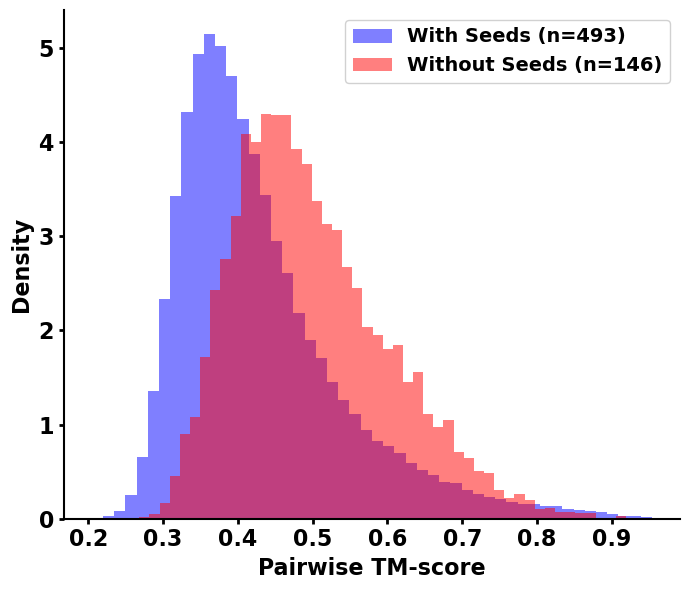

✓ pairwise_tm_distribution_c26.png


In [12]:
seed_triu    = K_sf[np.triu_indices_from(K_sf, k=1)]
nonseed_triu = K_nf[np.triu_indices_from(K_nf, k=1)]

print(f"Seed pairwise TM:    mean={seed_triu.mean():.3f},    median={np.median(seed_triu):.3f}")
print(f"Nonseed pairwise TM: mean={nonseed_triu.mean():.3f}, median={np.median(nonseed_triu):.3f}")

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.hist(seed_triu,    bins=50, density=True, alpha=0.5, color='blue', edgecolor='none',
        label=f'With Seeds (n={K_sf.shape[0]})')
ax.hist(nonseed_triu, bins=50, density=True, alpha=0.5, color='red',  edgecolor='none',
        label=f'Without Seeds (n={K_nf.shape[0]})')

ax.set_xlabel('Pairwise TM-score', fontsize=16, fontweight='bold')
ax.set_ylabel('Density',           fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=16, width=2)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
for lb in ax.get_xticklabels() + ax.get_yticklabels():
    lb.set_fontweight('bold')

legend = ax.legend(fontsize=14, loc='upper right', framealpha=0.9)
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
plt.savefig('pairwise_tm_distribution_c26.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ pairwise_tm_distribution_c26.png")


## 6. Cumulative cluster coverage

Fraction of designs covered by the *k* largest clusters, ranked by size. A reference line marks the cluster count at which the unseeded set is fully covered.

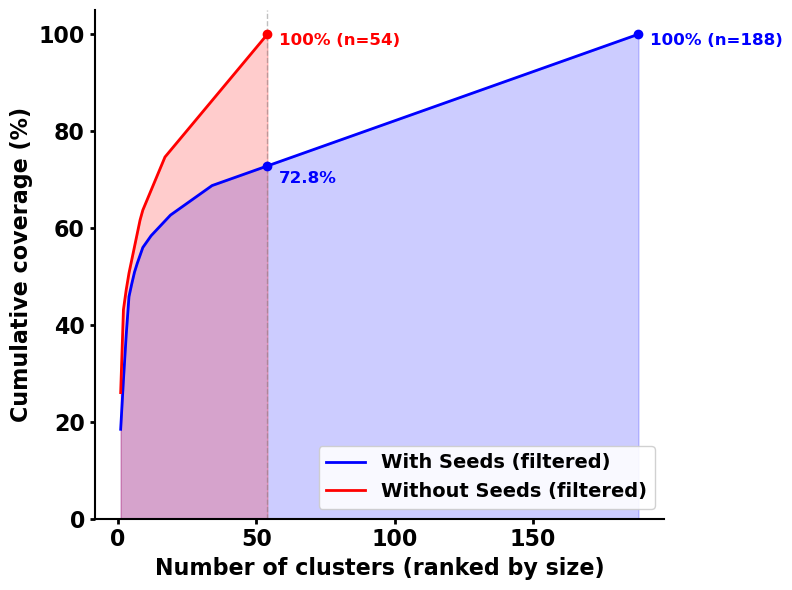

At 54 clusters: seed covers 72.8%
Seed reaches 100% at n=188
Nonseed reaches 100% at n=54
✓ cumulative_coverage_tm05_c26.png


In [13]:
seed_cumul    = np.cumsum(seed_sizes.values)    / seed_total    * 100
nonseed_cumul = np.cumsum(nonseed_sizes.values) / nonseed_total * 100
x_s, x_n = np.arange(1, len(seed_cumul) + 1), np.arange(1, len(nonseed_cumul) + 1)

n_seed_clusters    = len(seed_sizes)
n_nonseed_clusters = len(nonseed_sizes)
seed_cumul_at_nonseed_n = seed_cumul[min(n_nonseed_clusters - 1, len(seed_cumul) - 1)]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(x_s, seed_cumul,    color='blue', linewidth=2, label='With Seeds (filtered)')
ax.fill_between(x_s, seed_cumul,    alpha=0.2, color='blue')
ax.plot(x_n, nonseed_cumul, color='red',  linewidth=2, label='Without Seeds (filtered)')
ax.fill_between(x_n, nonseed_cumul, alpha=0.2, color='red')

# Reference line at the unseeded cluster count
ax.axvline(n_nonseed_clusters, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.plot(n_nonseed_clusters, seed_cumul_at_nonseed_n, 'o', color='blue', markersize=6, zorder=5)
ax.annotate(f'{seed_cumul_at_nonseed_n:.1f}%',
            (n_nonseed_clusters, seed_cumul_at_nonseed_n),
            textcoords='offset points', xytext=(8, -12),
            fontsize=12, fontweight='bold', color='blue')

ax.plot(n_nonseed_clusters, 100, 'o', color='red', markersize=6, zorder=5)
ax.annotate(f'100% (n={n_nonseed_clusters})', (n_nonseed_clusters, 100),
            textcoords='offset points', xytext=(8, -8),
            fontsize=12, fontweight='bold', color='red')

ax.plot(n_seed_clusters, 100, 'o', color='blue', markersize=6, zorder=5)
ax.annotate(f'100% (n={n_seed_clusters})', (n_seed_clusters, 100),
            textcoords='offset points', xytext=(8, -8),
            fontsize=12, fontweight='bold', color='blue')

ax.set_xlabel('Number of clusters (ranked by size)', fontsize=16, fontweight='bold')
ax.set_ylabel('Cumulative coverage (%)',             fontsize=16, fontweight='bold')
ax.set_ylim(0, 105)
ax.tick_params(axis='both', labelsize=16, width=2)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

legend = ax.legend(fontsize=14, loc='lower right', framealpha=0.9)
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
plt.savefig('cumulative_coverage_tm05_c26.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"At {n_nonseed_clusters} clusters: seed covers {seed_cumul_at_nonseed_n:.1f}%")
print(f"Seed reaches 100% at n={n_seed_clusters}")
print(f"Nonseed reaches 100% at n={n_nonseed_clusters}")
print("✓ cumulative_coverage_tm05_c26.png")


## 7. Top-5 cluster rank

Mirrored bar plot showing the share of the filtered ensemble captured by each of the five largest clusters in either condition. The unseeded panel (red, top) is dominated by a small number of large clusters; the seeded panel (blue, bottom) is more uniformly distributed.

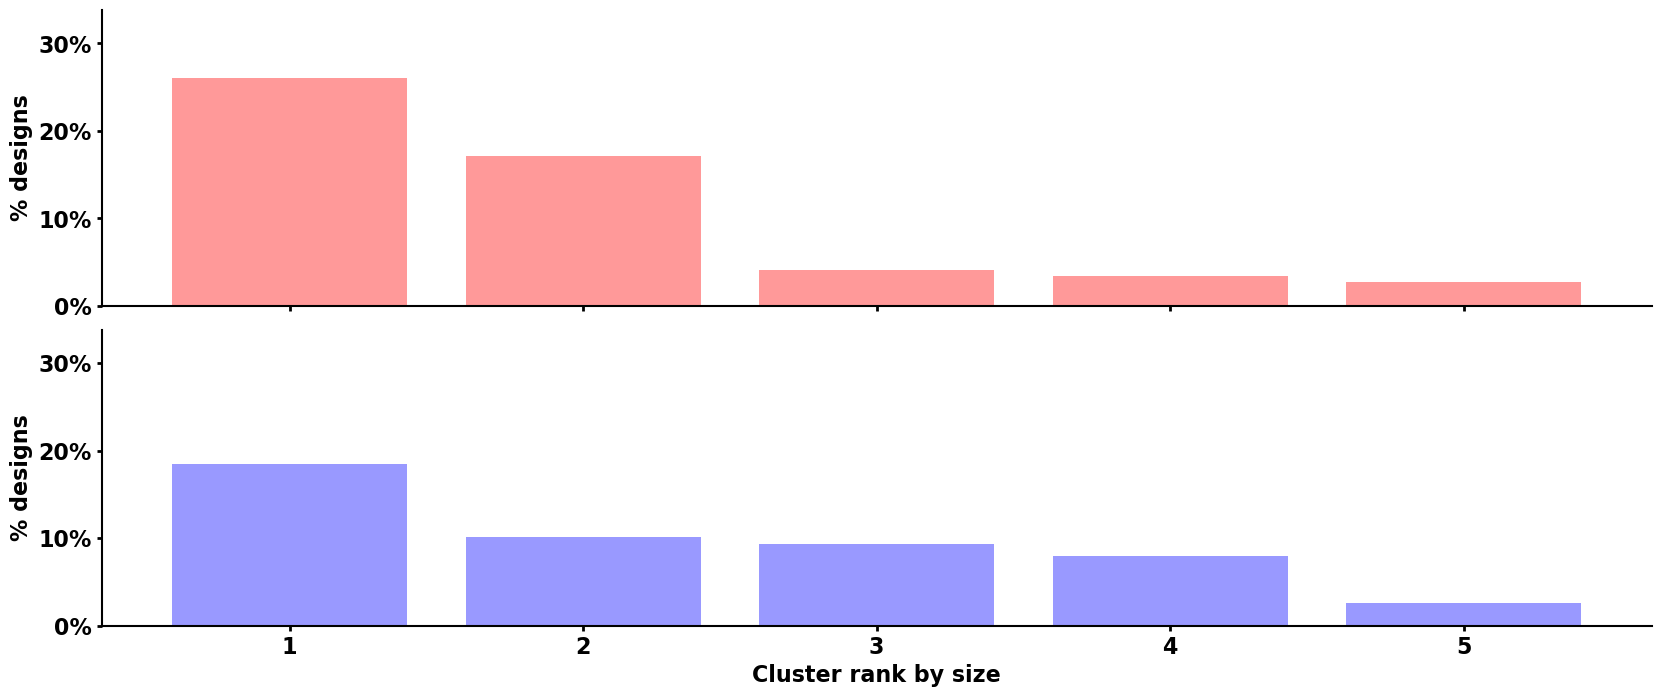

  Seed top-5:    ['18.5% (n=91)', '10.1% (n=50)', '9.3% (n=46)', '7.9% (n=39)', '2.6% (n=13)']
  Nonseed top-5: ['26.0% (n=38)', '17.1% (n=25)', '4.1% (n=6)', '3.4% (n=5)', '2.7% (n=4)']
  Seed top-5 cumulative:    239/493 (48.5%)
  Nonseed top-5 cumulative: 78/146 (53.4%)
✓ top5_clusters_tm05_c26.png


In [14]:
seed_top5_pct    = (100 * seed_sizes    / seed_total).head(5).values
nonseed_top5_pct = (100 * nonseed_sizes / nonseed_total).head(5).values
seed_top5_n      = seed_sizes.head(5).values
nonseed_top5_n   = nonseed_sizes.head(5).values

y_upper = max(seed_top5_pct.max(), nonseed_top5_pct.max()) * 1.3
cluster_ranks = range(1, 6)

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(20, 8))

ax_top.bar(cluster_ranks, nonseed_top5_pct, color='red', alpha=0.4, edgecolor='none')
ax_top.set_ylabel('% designs', fontsize=16, fontweight='bold')
ax_top.set_ylim(0, y_upper)
ax_top.set_xticks(list(cluster_ranks))
ax_top.tick_params(axis='x', labelbottom=False)
ax_top.tick_params(axis='both', labelsize=16, width=2)
for label in ax_top.get_yticklabels():
    label.set_fontweight('bold')

ax_bot.bar(cluster_ranks, seed_top5_pct, color='blue', alpha=0.4, edgecolor='none')
ax_bot.set_xlabel('Cluster rank by size', fontsize=16, fontweight='bold')
ax_bot.set_ylabel('% designs',            fontsize=16, fontweight='bold')
ax_bot.set_ylim(0, y_upper)
ax_bot.set_xticks(list(cluster_ranks))
ax_bot.set_xticklabels(list(cluster_ranks))
ax_bot.tick_params(axis='both', labelsize=16, width=2)
for label in ax_bot.get_xticklabels() + ax_bot.get_yticklabels():
    label.set_fontweight('bold')

for ax in (ax_top, ax_bot):
    ax.yaxis.set_major_formatter(FuncFormatter(pct_fmt))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

plt.subplots_adjust(hspace=0.08)
plt.savefig('top5_clusters_tm05_c26.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"  Seed top-5:    {[f'{p:.1f}% (n={n})' for p, n in zip(seed_top5_pct,    seed_top5_n)]}")
print(f"  Nonseed top-5: {[f'{p:.1f}% (n={n})' for p, n in zip(nonseed_top5_pct, nonseed_top5_n)]}")
print(f"  Seed top-5 cumulative:    {seed_top5_n.sum()}/{seed_total} "
      f"({100 * seed_top5_n.sum() / seed_total:.1f}%)")
print(f"  Nonseed top-5 cumulative: {nonseed_top5_n.sum()}/{nonseed_total} "
      f"({100 * nonseed_top5_n.sum() / nonseed_total:.1f}%)")
print("✓ top5_clusters_tm05_c26.png")


## 8. Secondary-structure ternary plots

STRIDE-derived α-helix / β-sheet / coil composition for each filtered ensemble, plotted on the standard ternary triangle. The hollow circle marks the centroid.

### 8a. Seed-guided

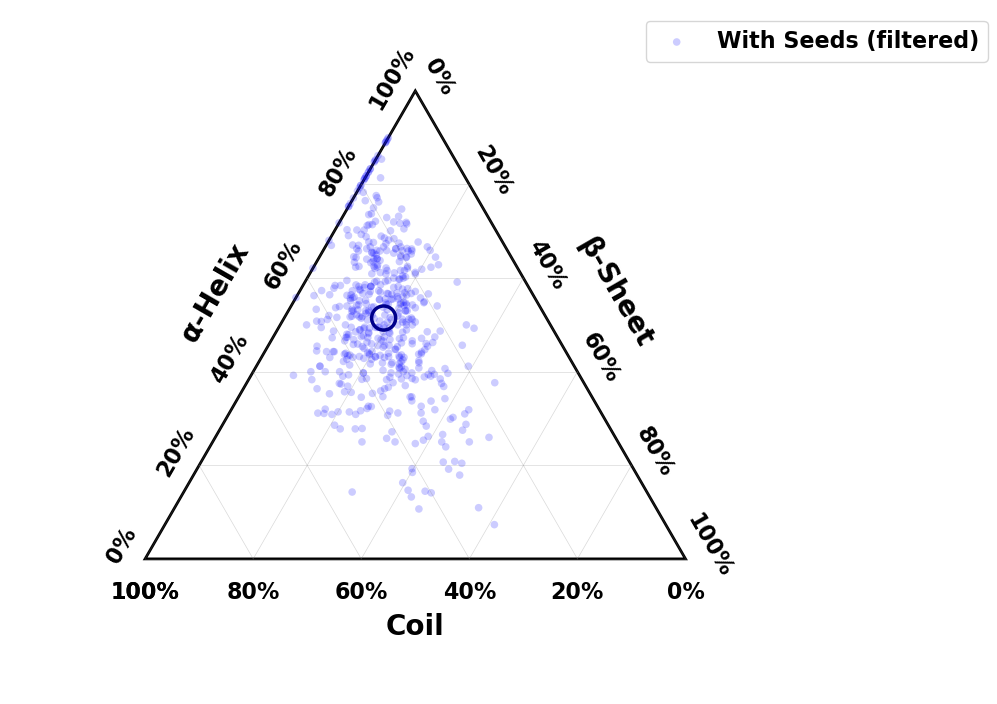

  With Seeds (filtered): n=493
    Centroid: H=51.5%, B=18.4%, C=30.1%
✓ ternary_seed_only.png


In [15]:
ss = calc_structure_ss(seed_filt)

fig, ax = styled_ternary_axes()
sx, sy = ternary_to_cartesian(ss['Helix_Norm'], ss['Beta_Sheet_Norm'], ss['Coil_Norm'])
ax.scatter(sx, sy, s=30, c='blue', alpha=0.2, edgecolors='none', label='With Seeds (filtered)')

cx, cy = ternary_to_cartesian(ss['Helix_Norm'].mean(),
                               ss['Beta_Sheet_Norm'].mean(),
                               ss['Coil_Norm'].mean())
ax.scatter(cx, cy, s=300, facecolors='none', edgecolors='darkblue', linewidth=2.5, zorder=10)

finalize_ternary(ax)
legend1 = ax.legend(fontsize=16, loc='upper right', bbox_to_anchor=(1.22, 1.0))
for text in legend1.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
plt.savefig('ternary_seed_only.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"  With Seeds (filtered): n={len(seed_filt)}")
print(f"    Centroid: H={ss['Helix_Norm'].mean():.1f}%, "
      f"B={ss['Beta_Sheet_Norm'].mean():.1f}%, C={ss['Coil_Norm'].mean():.1f}%")
print("✓ ternary_seed_only.png")


### 8b. Non-seed control

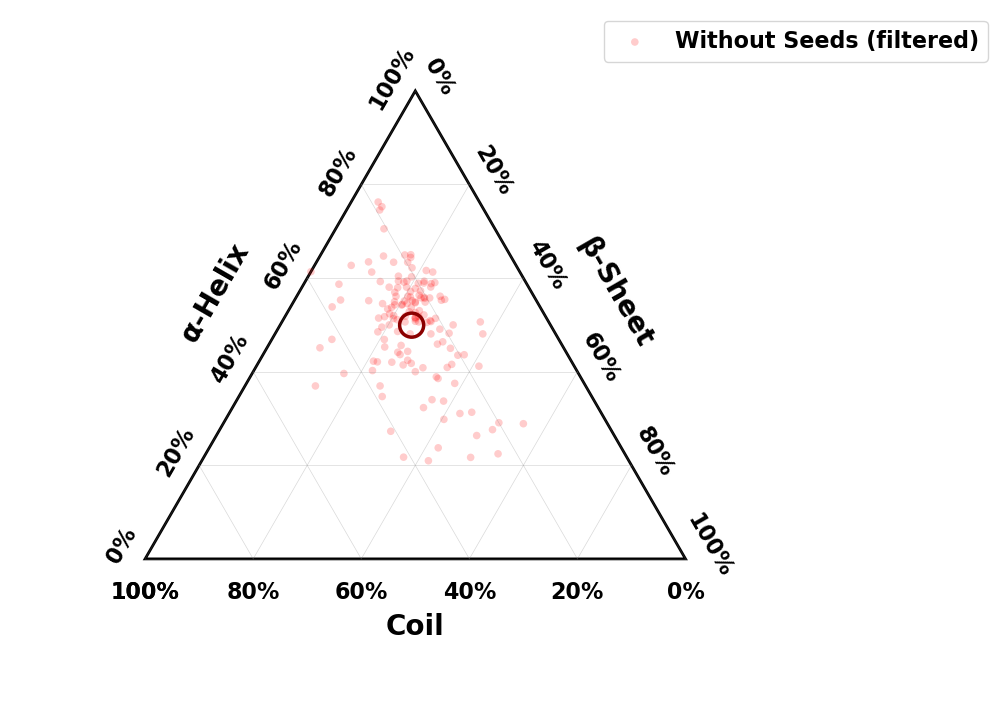

  Without Seeds (filtered): n=146
    Centroid: H=49.9%, B=24.3%, C=25.7%
✓ ternary_nonseed_only.png


In [16]:
ss = calc_structure_ss(nonseed_filt)

fig, ax = styled_ternary_axes()
sx, sy = ternary_to_cartesian(ss['Helix_Norm'], ss['Beta_Sheet_Norm'], ss['Coil_Norm'])
ax.scatter(sx, sy, s=30, c='red', alpha=0.2, edgecolors='none', label='Without Seeds (filtered)')

cx, cy = ternary_to_cartesian(ss['Helix_Norm'].mean(),
                               ss['Beta_Sheet_Norm'].mean(),
                               ss['Coil_Norm'].mean())
ax.scatter(cx, cy, s=300, facecolors='none', edgecolors='darkred', linewidth=2.5, zorder=10)

finalize_ternary(ax)
legend1 = ax.legend(fontsize=16, loc='upper right', bbox_to_anchor=(1.22, 1.0))
for text in legend1.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
plt.savefig('ternary_nonseed_only.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"  Without Seeds (filtered): n={len(nonseed_filt)}")
print(f"    Centroid: H={ss['Helix_Norm'].mean():.1f}%, "
      f"B={ss['Beta_Sheet_Norm'].mean():.1f}%, C={ss['Coil_Norm'].mean():.1f}%")
print("✓ ternary_nonseed_only.png")


### 8c. BindCraft (external benchmark)

BindCraft uses a different contacts column name (`contacts`) but the same cutoffs are applied in §2.

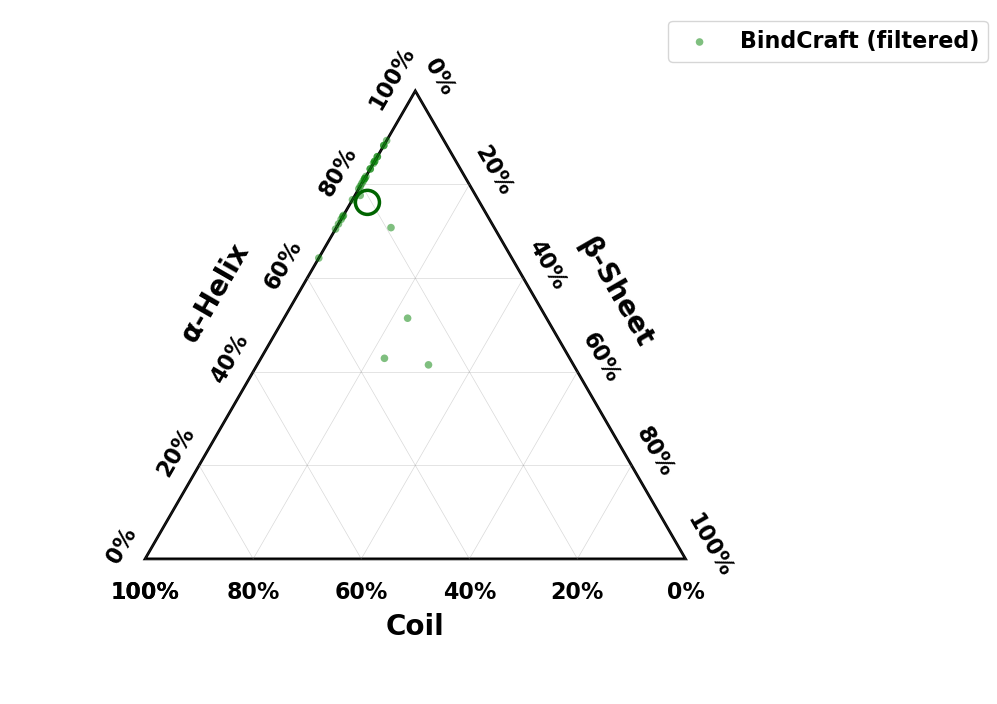

  BindCraft (filtered): n=29
    α-Helix: 76.2% ± 12.4%
    β-Sheet: 3.1% ± 8.2%
    Coil:    20.8% ± 6.6%
✓ ternary_bindcraft_c26_ipae10.png


In [17]:
bc_ss = calc_structure_ss(bindcraft_filt)

fig, ax = styled_ternary_axes()
bx, by = ternary_to_cartesian(bc_ss['Helix_Norm'], bc_ss['Beta_Sheet_Norm'], bc_ss['Coil_Norm'])
ax.scatter(bx, by, s=30, c='green', alpha=0.5, edgecolors='none', label='BindCraft (filtered)')

cx, cy = ternary_to_cartesian(bc_ss['Helix_Norm'].mean(),
                               bc_ss['Beta_Sheet_Norm'].mean(),
                               bc_ss['Coil_Norm'].mean())
ax.scatter(cx, cy, s=300, facecolors='none', edgecolors='darkgreen', linewidth=2.5, zorder=10)

finalize_ternary(ax)
legend1 = ax.legend(fontsize=16, loc='upper right', bbox_to_anchor=(1.22, 1.0))
for text in legend1.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
plt.savefig('ternary_bindcraft_c26_ipae10.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"  BindCraft (filtered): n={len(bindcraft_filt)}")
print(f"    α-Helix: {bc_ss['Helix_Norm'].mean():.1f}% ± {bc_ss['Helix_Norm'].std():.1f}%")
print(f"    β-Sheet: {bc_ss['Beta_Sheet_Norm'].mean():.1f}% ± {bc_ss['Beta_Sheet_Norm'].std():.1f}%")
print(f"    Coil:    {bc_ss['Coil_Norm'].mean():.1f}% ± {bc_ss['Coil_Norm'].std():.1f}%")
print("✓ ternary_bindcraft_c26_ipae10.png")
